# 🏥 Lung Cancer Histopathology Classification using DeiT Transformer

This notebook implements a state-of-the-art **Data-efficient Image Transformer (DeiT)** for classifying lung cancer pathology images. We transition from a basic CNN approach to a transformer-based architecture for better feature extraction and classification accuracy.

### 🚀 Model Architecture: DeiT (Data-efficient Image Transformer)

DeiT is a transformer-based model developed by Facebook AI (Meta AI) that is pre-trained to be high-performance even without massive datasets, making it ideal for medical imaging tasks like lung cancer classification.


In [1]:
# %% 📥 INSTALL DEPENDENCIES
!pip install transformers torch torchvision scikit-learn matplotlib seaborn pillow accelerate --quiet


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# %% 📦 IMPORTS
from typing import Literal
import os
from os.path import join
import torch
import numpy as np
from pathlib import Path
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm.auto import tqdm

# Hugging Face Transformers
from transformers import (
    DeiTImageProcessor, 
    DeiTForImageClassification, 
    TrainingArguments, 
    Trainer, 
    get_scheduler
)

d:\Programming\Project\Final year project\Hybrid CNN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Device: cpu


In [ ]:
# %% ⚙️ CONFIGURATION
# ── Paths ────────────────────────────────────────────────────────────────────
path = ".."
output = ".."
kaggle = False

if kaggle:
    path = "/kaggle/input/datasets/ebadansari/dataset"
    output = join("kaggle", "working")

dataset: Literal["ct-scan", "pathalogy"] = "pathalogy"
DATA_DIR   = Path(join(path, 'dataset', dataset))   # adjust if needed
SAVE_DIR   = Path(join(output, 'outputs/resnet'))
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "facebook/deit-base-distilled-patch16-224" # Base DeiT model
IMAGE_SIZE = 224
BATCH_SIZE = 8 # Reduced for memory safety on larger transformer models
EPOCHS = 5      # Transformers learn fast, so we start with 5
SAMPLE_RATE = 0.25 # To match previous model's data usage
LR = 5e-5       # Typical learning rate for fine-tuning
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Mapping folders to labels
if dataset == "ct-scan":
    label_map = {
        "norm": 0,   # Normal (Benign)
        "aca": 1, # Adenocarcinoma
        "scc": 2  # Squamous Cell Carcinoma
    }
    label_names = ["Benign", "Adenocarcinoma", "Squamous Cell Carcinoma"]

elif dataset == "pathalogy":
    label_map = {
        "norm": 0, # Normal (Benign)
        "aca": 1, # Adenocarcinoma
        "scc": 2, # Squamous Cell Carcinoma
        "lcc": 3 # Large Cell Carcinoma
    }
    label_names = ["Benign", "Adenocarcinoma", "Squamous Cell Carcinoma", "Large Cell Carcinoma"]


print(f"Using Device: {DEVICE}")


## 📂 Data Loading & Preprocessing

We create a custom PyTorch dataset to handle the 25% sampling logic and use the `DeiTImageProcessor` for proper normalization and resizing required by the transformer model.


In [ ]:
class LungCancerDataset(Dataset):
    def __init__(self, data_list, labels, processor):
        self.data_list = data_list
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path = self.data_list[idx]
        label = self.labels[idx]
        
        # Load and convert to RGB
        image = Image.open(img_path).convert("RGB")
        
        # Use DeiT processor for resizing and normalization
        inputs = self.processor(images=image, return_tensors="pt")
        
        # The processor returns tensors with an extra batch dimension, so we remove it
        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

def prepare_data(path, sample_rate=0.25):
    all_image_paths = []
    all_labels = []

    for folder, label_idx in label_map.items():
        class_dir = os.path.join(path, folder)
        if not os.path.exists(class_dir):
            print(f"⚠️ Warning: Folder {folder} not found in {path}")
            continue
            
        files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Sampling for consistent comparison with previous model
        num_to_sample = int(len(files) * sample_rate)
        sampled = random.sample(files, num_to_sample)
        
        all_image_paths.extend(sampled)
        all_labels.extend([label_idx] * len(sampled))

    return all_image_paths, all_labels

print("🔍 Sampling dataset...")
paths, labels = prepare_data(DATA_DIR, sample_rate=SAMPLE_RATE)

# Split into Train (80%) and Test (20%)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    paths, labels, test_size=0.2, random_state=42, stratify=labels
)

# Initialize Image Processor
image_processor = DeiTImageProcessor.from_pretrained(MODEL_NAME)

# Create Datasets
train_dataset = LungCancerDataset(train_paths, train_labels, image_processor)
test_dataset = LungCancerDataset(test_paths, test_labels, image_processor)

print(f"✅ Data Split: Train={len(train_dataset)}, Test={len(test_dataset)}")

🔍 Sampling dataset...
✅ Data Split: Train=140, Test=36


## 🧠 Building the DeiT Model

We load a pre-trained **DeiT** model and replace its classification head with a new one suitable for our 3 lung cancer classes.


In [4]:
print(f"🧠 Loading {MODEL_NAME}...")

model = DeiTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    ignore_mismatched_sizes=True # Necessary to resize the final classification layer
)

model.to(DEVICE)
print("✅ Model Loaded Successfully!")

🧠 Loading facebook/deit-base-distilled-patch16-224...


You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14137.31it/s]
DeiTForImageClassification LOAD REPORT from: facebook/deit-base-distilled-patch16-224
Key                            | Status     | 
-------------------------------+------------+-
distillation_classifier.bias   | UNEXPECTED | 
cls_classifier.bias            | UNEXPECTED | 
cls_classifier.weight          | UNEXPECTED | 
distillation_classifier.weight | UNEXPECTED | 
classifier.weight              | MISSING    | 
classifier.bias                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model Loaded Successfully!


## 🏋️ Training the Model

We'll use a standard training loop with AdamW optimizer and a linear scheduler.


In [5]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
num_training_steps = len(train_loader) * EPOCHS
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

history = {"train_loss": [], "val_acc": []}

print("🚀 Starting Training...")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in progress_bar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})
    
    avg_loss = total_loss / len(train_loader)
    history["train_loss"].append(avg_loss)
    
    # Validation step 
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=-1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    history["val_acc"].append(val_acc)
    
    print(f"📈 Epoch {epoch+1} Summary: Train Loss = {avg_loss:.4f}, Val Acc = {val_acc:.4f}")

🚀 Starting Training...


Epoch 1/5:  56%|█████▌    | 10/18 [01:45<01:09,  8.63s/it, loss=0.591]d:\Programming\Project\Final year project\Hybrid CNN\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\cw\.cache\huggingface\hub\models--facebook--deit-base-distilled-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Epo

📈 Epoch 1 Summary: Train Loss = 0.7993, Val Acc = 0.6111


Epoch 2/5: 100%|██████████| 18/18 [01:48<00:00,  6.05s/it, loss=0.102]


📈 Epoch 2 Summary: Train Loss = 0.2700, Val Acc = 0.8333


...

📈 Epoch 3 Summary: Train Loss = 0.0696, Val Acc = 0.7778


Epoch 4/5: 100%|██████████| 18/18 [01:34<00:00,  5.23s/it, loss=0.00837]


📈 Epoch 4 Summary: Train Loss = 0.0187, Val Acc = 0.8333


Epoch 5/5: 100%|██████████| 18/18 [01:32<00:00,  5.16s/it, loss=0.0123] 


📈 Epoch 5 Summary: Train Loss = 0.0129, Val Acc = 0.8056


## 📈 Training Results

Visualizing the loss and accuracy over time.


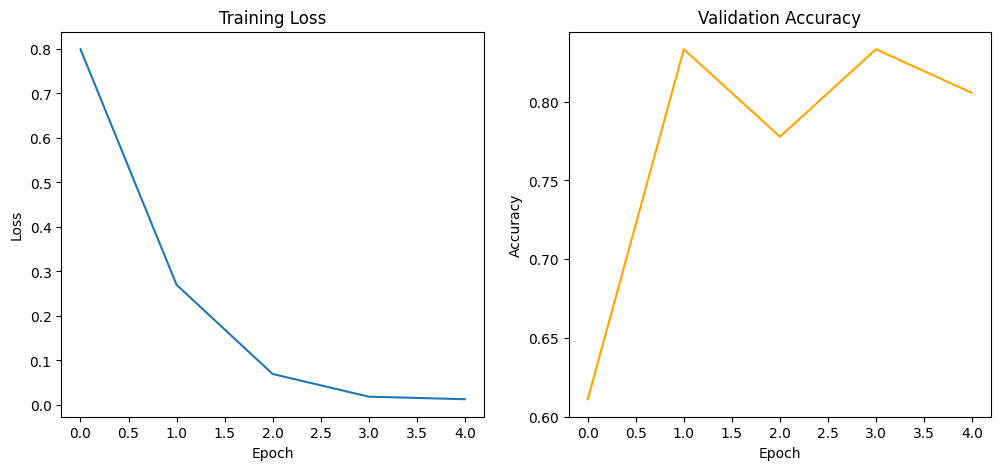

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["val_acc"], label="Val Acc", color='orange')
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

## 🔍 Evaluation & Confusion Matrix

Detailed analysis of the model's performance.


Final Eval: 100%|██████████| 5/5 [00:09<00:00,  1.94s/it]


🎯 Final Accuracy: 0.8055555555555556

📋 Classification Report:
                          precision    recall  f1-score   support

                 Benign       0.89      1.00      0.94         8
         Adenocarcinoma       0.81      0.81      0.81        16
Squamous Cell Carcinoma       0.73      0.67      0.70        12

               accuracy                           0.81        36
              macro avg       0.81      0.83      0.82        36
           weighted avg       0.80      0.81      0.80        36



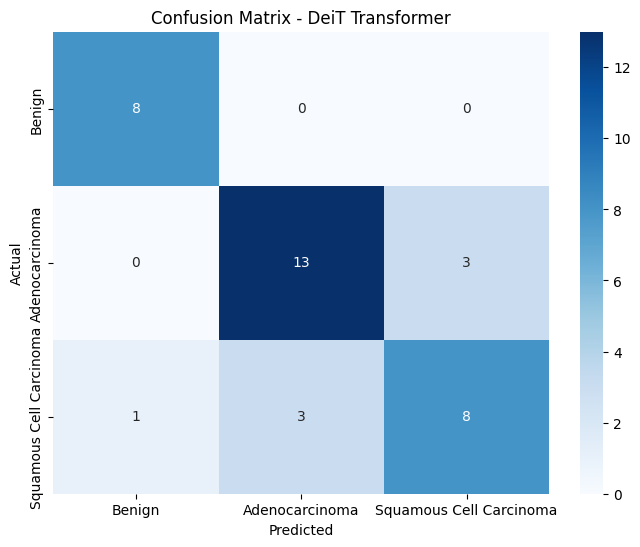

In [7]:
# Final Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Final Eval"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

print("🎯 Final Accuracy:", accuracy_score(all_labels, all_preds))
print("\n📋 Classification Report:\n", classification_report(all_labels, all_preds, target_names=label_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DeiT Transformer")
plt.show()

## 🖼️ Sample Predictions

Looking at some images and their predicted labels.


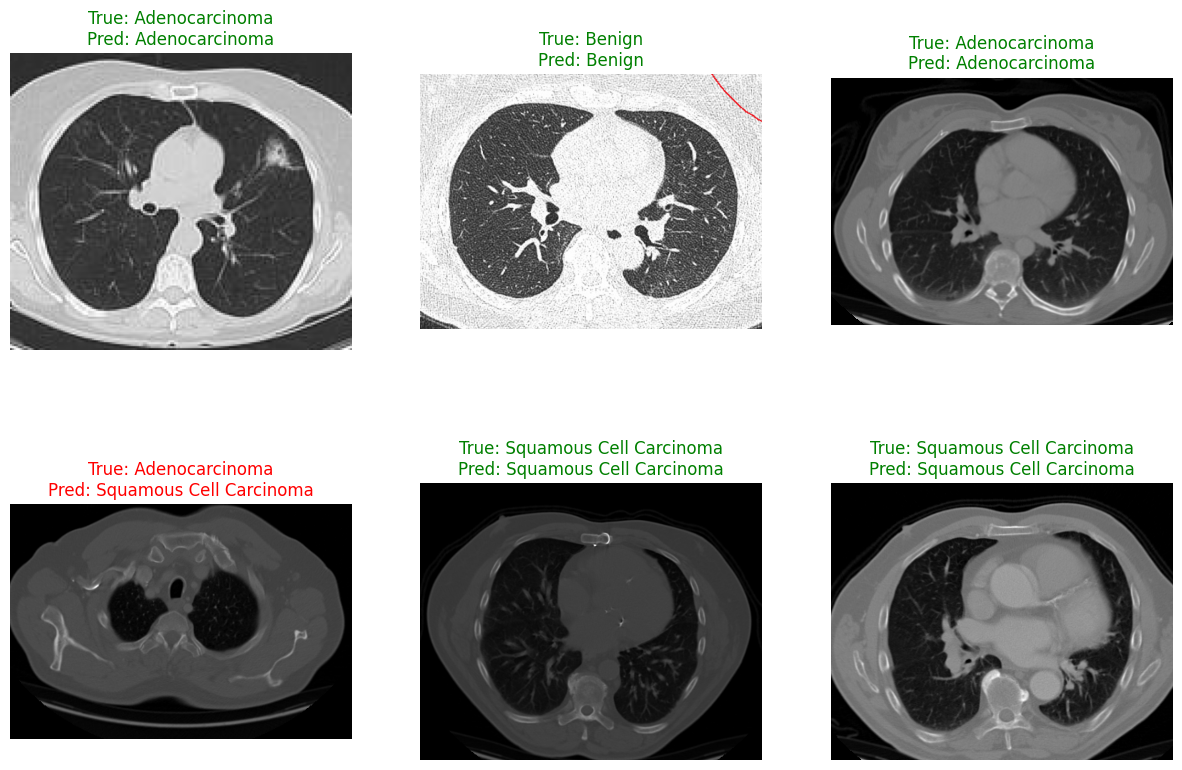

In [8]:
plt.figure(figsize=(15, 10))
indices = random.sample(range(len(test_paths)), min(6, len(test_paths)))

for i, idx in enumerate(indices):
    img_path = test_paths[idx]
    true_label = label_names[test_labels[idx]]
    
    img = Image.open(img_path).convert("RGB")
    inputs = image_processor(images=img, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        logits = model(**inputs).logits
        pred_idx = torch.argmax(logits, dim=-1).item()
        pred_label = label_names[pred_idx]
        
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=("green" if true_label == pred_label else "red"))
    plt.axis("off")

plt.show()

## 💾 Save the Model

Save the fine-tuned model for later use.


In [9]:
save_directory = "lung_cancer_deit_model_ct-scan"
model.save_pretrained(save_directory)
image_processor.save_pretrained(save_directory)
print(f"✅ Model and Processor saved to '{save_directory}'")

Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.33s/it]

✅ Model and Processor saved to 'lung_cancer_deit_model_ct-scan'
